# Importing Required Libraries

In [1]:
# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Audio specific packages
import librosa
from IPython.display import Audio, display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torch.optim as optim 
import torchaudio.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

from glob import glob
import random
from tqdm import tqdm
import soundfile as sf

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os

from sklearn.metrics import f1_score , accuracy_score, classification_report, confusion_matrix
import math

device: cuda


# Data Loader

In [2]:
class test_mashed_dataset(Dataset):
    def __init__(self, path, test_csv, sr, duration):
        self.path = path
        self.test_csv = test_csv
        self.sr = sr
        self.duration = duration
        self.num_samples = int(duration * sr)

        # Mel transform
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sr, # number of samples per second 16000 in this case
            n_fft=400,        # 400 frequency bins the fourier tranform calculates
            win_length=400,   # 400 samples are analyzed at one moment for creating spectrogram
            hop_length=160 ,  # 160 samples the window slides after each calculation
            n_mels=128,        # 128 frequency bands
            f_min=0,          # minimun frequency 
            f_max=8000,       # maximum frequency
            normalized=True,   # normalization
        )
        
        # self.db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.test_csv)

    def __getitem__(self,index):
        filename = test_csv.iloc[index][0]
        path = self.path+filename
        
        """Load and preprocess audio."""
        audio, sr = torchaudio.load(path)
        
        if sr != self.sr:         # correct sample rate
            audio = torchaudio.functional.resample(audio, sr, self.sr)
        
        if audio.shape[0] > 1:    # ensure mono audio
            audio = audio.mean(0, keepdim=True)

        total_samples = audio.shape[-1]
        
        samples = math.ceil(total_samples/self.num_samples)

        test_data = []
                            
        for i in range(samples):  # breaking one test samples into 10.24 sec parts
            start = i*self.num_samples
            end = start+self.num_samples

            audio_chunk = audio[:,start:end]
            
            if audio_chunk.shape[-1] < self.num_samples:
                audio_chunk = torch.nn.functional.pad(audio_chunk, (0, self.num_samples- audio_chunk.shape[-1]))

            audio_mel = self.mel(audio_chunk)
            mel_db = torch.log(audio_mel + 1e-6)

            mean = mel_db.mean()
            std = mel_db.std()
            
            mel_db = (mel_db - mean) / (std + 1e-6)
                
            test_data.append(mel_db)

        return torch.stack(test_data)   # chunks, channel, height, width

In [3]:
test_csv = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv" , index_col='id')
sample_submission = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv" , index_col='id' )
path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/"

In [4]:
test_data = test_mashed_dataset(path, test_csv, 16000, 10.24)
# batch_size 1 for test data so all audio chunk can be processed together
test_loader = DataLoader(test_data , batch_size=1, shuffle=False, num_workers=4,pin_memory=True)

# CNN

In [5]:
class CNN_mashup_model(nn.Module):
    def __init__(self, layers, n, sr ,dr,fl):
        """
            layers: Number of CNN layer
            n: size of kernel 
            sr: sample rate of music 
            dr: dropout rate
            fl: number of start filters
        """
        super().__init__()
        self.layers = layers
        self.n = n
        self.sr = sr
        self.dr = dr


        CNN_models = []
        self.prev_channel = 1 

        for i in range(self.layers):
            
            out_channels = min(fl * (2**i), 512)
             
            CNN_models.extend([
                nn.Conv2d(in_channels=self.prev_channel, 
                          out_channels=out_channels, 
                          kernel_size=self.n, 
                          padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
                nn.Dropout(self.dr)
            ])
            self.prev_channel = out_channels

        self.CNN_model = nn.Sequential(*CNN_models)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(in_features=self.prev_channel, out_features=10)

    def forward(self,x):
        
        x = self.CNN_model(x)
        x = self.global_pool(x)
        x = self.flatten(x)
        logits = self.classifier(x)
        
        return logits
    

In [6]:
def prediction(model,test_loader):
    model.eval()
    predictions = []
    
    with torch.inference_mode():
        for x in tqdm(test_loader):
            x = x.squeeze(0) # (batch, Num_Chunks, 1, Freq, Time) -->  (Num_Chunks, 1, Freq, Time)
            x = x.to(device)
            logits = model(x)
            avg_logits = torch.mean(logits, dim=0, keepdim=True)
            
            _, predicted_classes = torch.max(avg_logits, 1)
            predictions.append(predicted_classes.item())
            
    return predictions

In [7]:
label_to_genre = {
    0: "blues", 1: "classical", 2: "country", 3: "disco", 4: "hiphop",
    5: "jazz", 6: "metal", 7: "pop", 8: "reggae", 9: "rock"
}

In [8]:
model = CNN_mashup_model(7,3,16000,0.2,32)
model.to(device)

CNN_mashup_model(
  (CNN_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.2, inplace=False)
    (15): Conv2d(128, 256, kernel_size=(

In [9]:
model.load_state_dict(torch.load("/kaggle/input/models/aryanchauhan97971234/scratch_cnn_3_4_v3/pytorch/7_3_22050_0.2_32/1/Scratch_CNN.pth"))

<All keys matched successfully>

In [10]:
preds = prediction(model,test_loader)
sample_submission['genre'] = [label_to_genre[i] for i in preds]

100%|██████████| 3020/3020 [01:03<00:00, 47.84it/s]


In [11]:
sample_submission.to_csv("submission.csv")

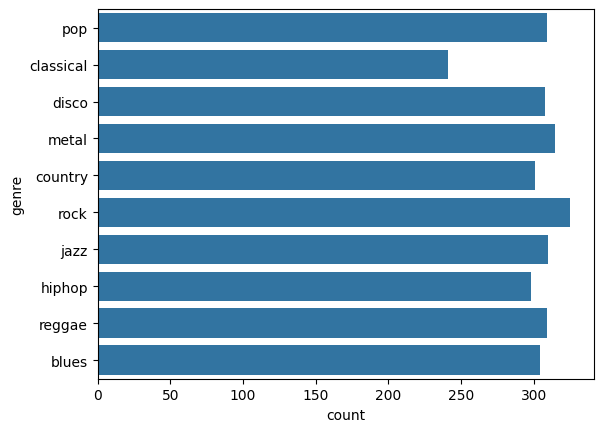

In [12]:
sns.countplot(sample_submission['genre'])
plt.show()